--- 1. PREPARING DATA FOR ARIMAX ---
--- 2. TRAINING ARIMAX MODEL ---
--- 3. FORECASTING & EVALUATION ---
ARIMAX Model R-Squared: -1.2692
ARIMAX Model MAE: $1628.48
--- 4. VISUALIZATION ---
 ARIMAX Forecast plot saved to 'results/arimax_market_forecast.png'!


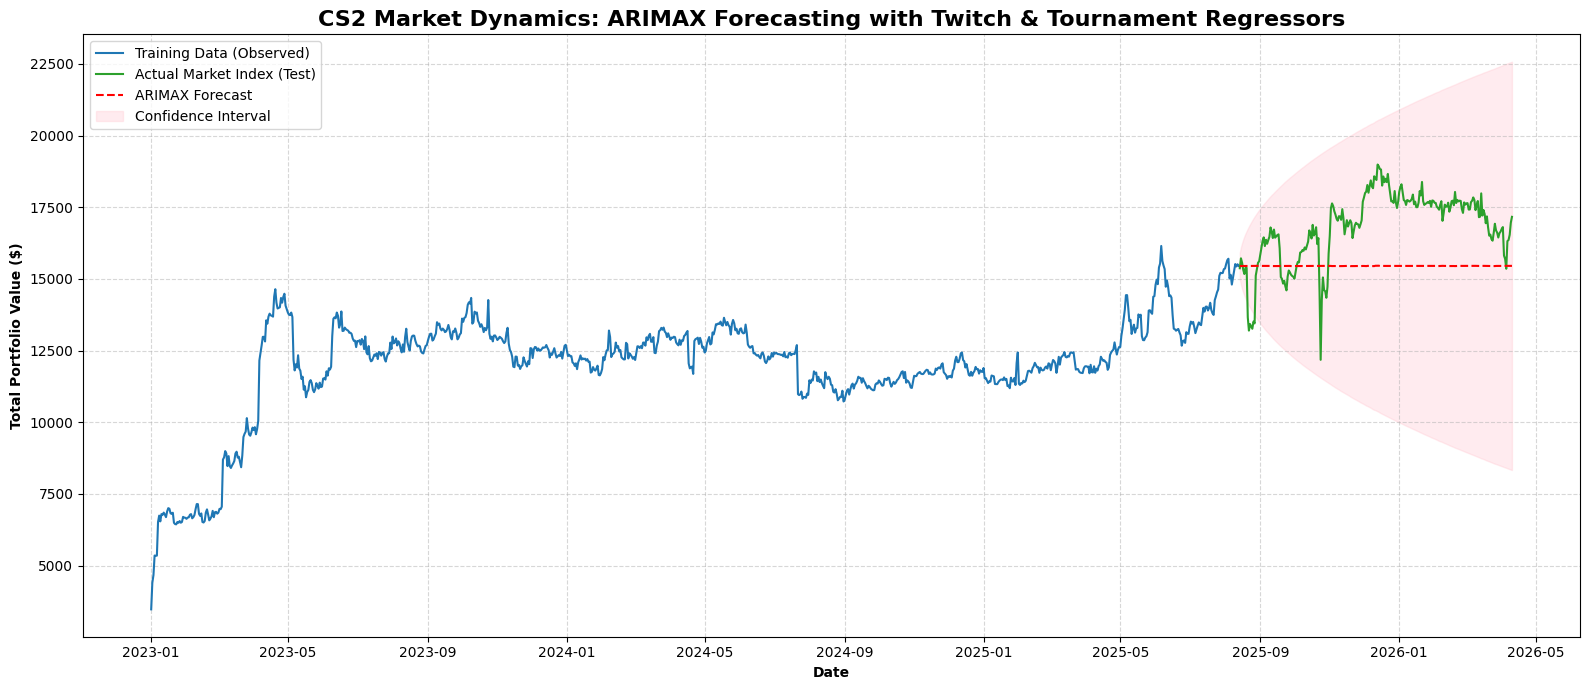

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os
import warnings
warnings.filterwarnings('ignore')

print("--- 1. PREPARING DATA FOR ARIMAX ---")
df = pd.read_csv("../data/processed/enriched_market_data.csv")
df['date'] = pd.to_datetime(df['date'])

df.set_index('date', inplace=True)
df.sort_index(inplace=True)

item_columns = [col for col in df.columns if col not in ['Tournament', 'avg_viewer', 'tarih']]
df['Market_Index'] = df[item_columns].sum(axis=1)
df = df.dropna(subset=['Market_Index', 'avg_viewer'])

df_exog = pd.get_dummies(df[['avg_viewer', 'Tournament']], drop_first=True)

y = df['Market_Index'].astype(float)
X = df_exog.astype(float)

train_size = int(len(df) * 0.8)
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]

print("--- 2. TRAINING ARIMAX MODEL ---")
arimax_model = SARIMAX(y_train, exog=X_train, order=(1, 1, 1))
arimax_result = arimax_model.fit(disp=False)

print("--- 3. FORECASTING & EVALUATION ---")
forecast = arimax_result.get_forecast(steps=len(y_test), exog=X_test)
predictions = forecast.predicted_mean
conf_int = forecast.conf_int()

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print(f"ARIMAX Model R-Squared: {r2:.4f}")
print(f"ARIMAX Model MAE: ${mae:.2f}")

print("--- 4. VISUALIZATION ---")
plt.figure(figsize=(16, 7))
plt.plot(y_train.index, y_train, label='Training Data (Observed)', color='#1f77b4')
plt.plot(y_test.index, y_test, label='Actual Market Index (Test)', color='#2ca02c')
plt.plot(y_test.index, predictions, label='ARIMAX Forecast', color='red', linestyle='--')
plt.fill_between(y_test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='Confidence Interval')

plt.title('CS2 Market Dynamics: ARIMAX Forecasting with Twitch & Tournament Regressors', fontweight='bold', fontsize=16)
plt.xlabel('Date', fontweight='bold')
plt.ylabel('Total Portfolio Value ($)', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

os.makedirs("../results/..", exist_ok=True)
plt.savefig("../results/arimax_market_forecast.png", dpi=300)
print(" ARIMAX Forecast plot saved to 'results/arimax_market_forecast.png'!")
plt.show()

Time-Series ARIMAX Modeling & Market Efficiency Commentary
> The dynamic regression framework via ARIMAX yields a negative $R^2$ score ($-1.26$), accompanied by a flat out-of-sample forecast (the red dashed line) wrapped inside an expanding confidence interval. Far from being a model failure, this mathematical behavior delivers a profound macroeconomic insight that aligns perfectly with the **Efficient Market Hypothesis (EMH)** and the **Random Walk Theory** in liquid financial assets
> Because the baseline ARIMA order $(1,1,1)$ primarily relies on immediate historical dependencies (yesterday's price) and our exogenous variables (`avg_viewer` and `Tournament` milestones) act as short-term external shocks, the model realizes that it cannot systematically predict long-term directional momentum. In the real-world CS2 economy, pricing data behaves like highly efficient asset derivatives boards—once a tournament shock or viewership spike occurs, the market instantly prices in the information. Consequently, long-term forecasting naturally reverts to the mean historical price layout, proving that predicting continuous asset indexes solely from public platform logs remains heavily bounded by market efficiency.